<a href="https://colab.research.google.com/github/anaguilarar/WeatherSoilDataProcessor/blob/main/google_colab_examples/dssat_spatial_crop_simulation_pixel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This notebook demonstrates how to perform a spatial crop simulation at a pixel-scale resolution using the WeatherSoilDataProcessor library and the DSSAT model. It covers downloading necessary spatial data (weather and soil), creating data cubes, and running the crop model simulation.

In [ ]:
!git clone https://github.com/anaguilarar/WeatherSoilDataProcessor.git

import os
os.chdir('/content/WeatherSoilDataProcessor')

!pip install -r /content/WeatherSoilDataProcessor/requirements.txt

In [13]:
!pip install hvplot panel param geoviews bokeh jupyter_bokeh -U
from google.colab import output
output.enable_custom_widget_manager()

# Run Spatial Crop Simulation at Pixel-Scale Resolution

This example demonstrates how to simulate the potential yield of a specific crop at a fine spatial resolution (250m), aligning with the SoilGrids project resolution. The simulation requires detailed information on soil and weather conditions, as well as specified management practices.

## Repository Structure

The repository is organized into three main components:

1. [**Crop Modeling Using Banana_n Model:**](#cropmodel)
   - Configuration file setup
   - Running Banana_n
   - Plotting the results

## 1. Crop Modeling Using the Banana_n Model<a id="cropmodel"></a>




### Spatial Data

In [ ]:
import os
input_fileid = '1_z2BOjCHuyG13rwPTMzSFfXNzmIHdh2x'

input_folder = 'bananan_guadalupe'

climate_path = 'bananan_guadalupe/weather_guadalupe_2021_2023.nc'
soil_path = 'bananan_guadalupe/soilgrids_guad.nc'
dem_path = 'bananan_guadalupe/guadalupe_dem.tif'
vector_path = "bananan_guadalupe/guadalupe_whole.shp"


if not os.path.exists(os.path.dirname(climate_path)): os.mkdir(os.path.dirname(climate_path))

soil_path = f'soil/soil_{cs}.nc'
if not os.path.exists(os.path.dirname(soil_path)): os.mkdir(os.path.dirname(soil_path))

if not os.path.exists(input_folder + '.zip'):
  !gdown --id {input_fileid} --output {input_folder + '.zip'}



### Configuration file setup

To specify that the analysis will be done at pixel-scale, we set 'pixel' in the configuration dictionary.

Other parameters to configure include crop parameters and management practices.
Below is an example of how to define these parameters. For more examples, please check the options/dssat_options folder.

In [ ]:
import os
os.chdir('/content/WeatherSoilDataProcessor')
from crop_modeling.spatial_process import SpatialCM
import numpy as np
import pandas as pd
import geopandas as gpd

cm_configuration = {
    'GENERAL_INFO': {
        'country': 'Guadalupe',
        'country_code': 'GUAD', # crountry code
        'working_path': 'runs', # the model outputs will be located in this path
        'ncores': 5,
        'model': 'banana_n',
        'bin_path': None
    },
    'SPATIAL_INFO':{
        'geospatial_path': vector_path, # spatial file that contains the region of interest
        'feature_name': 'id', ## an unique code that represent each region of interest
        'adm_level': 2,
        'aggregate_by' : 'pixel',
        'soil_path' : soil_path,
        'weather_path': climate_path,
        'dem_path': dem_path,
        'scale_factor': 1 # scale factor for soil and weather spatial resolution combination. the scale resample is applied to the climate datacube 5 times represents ~1km
    },
    'CROP':{
        'name': 'Banana',
        'cultivar': None,
        
    },      
    'MANAGEMENT':{
        'planting_date': '2021-05-01',
        'plantingWindow': 20,
        'nweeks_cycle': 81
    }
}



### Running BANANA N

In [ ]:
# Initialize the spatial crop modeling class
cm_sp = SpatialCM(configuration_dict=cm_configuration)

feat_attr = cm_configuration['SPATIAL_INFO'].get('feature_name', None)
geocode = 97110
roi = cm_sp.geo_features.loc[cm_sp.geo_features[feat_attr]==str(geocode)]
roi_name = roi[cm_sp.config.SPATIAL_INFO.feature_name].values[0]
roi
cm_sp.set_up_folders(site = roi_name)

loaded from soil/soil_mwi.nc
loaded from weather/weather_mwi_2000_2019.nc


,shapeName,shapeISO,shapeID,shapeGroup,shapeType,geometry
27,Zomba,None,42251766B13881881574545,MWI,ADM2,"POLYGON ((35.03997 -15.32181, 35.04045 -15.321..."


<Axes: >

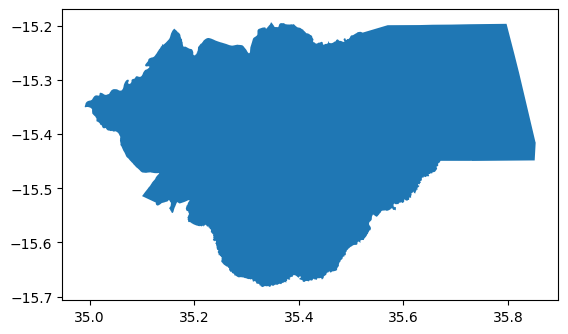

In [ ]:
roi.plot()

In [ ]:

import shutil
if os.path.exists(f'/content/WeatherSoilDataProcessor/runs/{geocode}'):
  shutil.rmtree(f'/content/WeatherSoilDataProcessor/runs/{geocode}', ignore_errors=False, onerror=None)

In [ ]:
workingpath = cm_sp.create_roi_sp_data(
     roi= roi,
     export_spatial_data= True
 )


if workingpath is not None:
    # Locate environmental working paths
    cm_sp.model.find_envworking_paths(cm_sp._tmp_path, 'WTH')
    cm_sp.model._enviroments = {}
    # Set up crop files
    nbweeks = cm_configuration['MANAGEMENT']['nweeks_cycle']
    planting_date = cm_configuration['MANAGEMENT']['planting_date']
    cm_sp.model.set_up_crop(starting_date= planting_date, time_step_weeks=2, cycle_duration_weeks = nbweeks)
    cm_sp.model.organize_enviromental_data()

    # Set up management files
    cm_sp.model.set_up_management(crop=cm_sp.crop, cultivar=cm_sp.cultivar, **cm_sp.config.MANAGEMENT)

    # run the simulation
    completed_sims = cm_sp.model.run()

    print(completed_sims)
else:
    print('there is no information')

### Crop simulation outputs

After completing the simulation, the next step is to generate the output maps.


In [ ]:

from crop_modeling.banana_n.output import update_banana_n_data_using_path
from crop_modeling.spatial_process import create_mlt_yield_raster
from crop_modeling.utils.output_transforms import summarize_spatial_yields_by_time_window
import rioxarray as rio
import matplotlib.pyplot as plt
import os



refraster = rio.open_rasterio(os.path.join(cm_sp._tmp_path,'ref_raster.tif'))
model_data = update_banana_n_data_using_path(cm_sp._tmp_path)

mlt_pot_yield = create_mlt_yield_raster(refraster, model_data, date_column = 'sowing_date', ycol_name ='fruit_yield', select_highest_value = True )
### Summarizing data by planting window


100%|██████████| 270/270 [00:01<00:00, 226.49it/s]


### Exporting the results

In [ ]:
from crop_modeling.utils.process import get_crs_fromxarray,set_encoding, check_crs_inxrdataset

dcengine = 'netcdf4'
encoding = set_encoding(mlt_pot_yield)
xrdata = check_crs_inxrdataset(mlt_pot_yield)
xrdata.to_netcdf(f'simulations_{cs}_{geocode}.nc', encoding = encoding, engine = dcengine)


dcengine = 'netcdf4'
encoding = set_encoding(summ_yield)
xrdata = check_crs_inxrdataset(summ_yield)
xrdata.to_netcdf(f'summarized_simulations_{cs}_{geocode}.nc', encoding = encoding, engine = dcengine)



### Paper comparison

In order to evaluate the accuracy of the Python implementation, four distinct comparisons were performed:
1. Python implementation using the conditions reported in the paper: climate data (weather station) and soil data (field measurements).
2. Python implementation using weather station data combined with SoilGrids data.
3. Python implementation using climate data derived from AgERA5 and CHIRPS (large-scale data) combined with field measurements.
4. Finally, Python implementation using climate data derived from AgERA5 and CHIRPS (large-scale data) combined with SoilGrids data.



1. Python implementation using the conditions reported in the paper:

In [ ]:
from crop_modeling.banana_n.base import BANANAField, soil_initial_conditions, banana_cycle_weekly_weather
from datetime import datetime, timedelta



ferti_mock = [{'application': False, 'q_org': 0.0, 'min_f': 0.0} for _ in range(nbweeks)]
papersweather = pd.read_csv("bananan_guadalupe/weather_80_weeks.csv")
papersweather = papersweather.to_dict(orient='records')
    
paper_soil_values = {'wsol1': 184.8,
 'wsol2': 197.4,
 'son': 9923.077,
 'smn_depth1': 70.96154,
 'smn_depth2': 50.44038}
 
densite = 1300
nban = 40

modelsoilpaper = BANANAField(nban=nban, density= densite, init_soil_parameters=paper_soil_values)
bananacycle = modelsoilpaper.simulate(nb_weeks = nbweeks, weather_data = papersweather, ferti_schedule = ferti_mock)
dfcycle = pd.DataFrame(bananacycle)

dfcycle['TOTBAN'] = (dfcycle['Avg_Bioamass_g_mat'] / 1000) * densite
dfcycle.plot('Week', 'TOTBAN')

2. Python implementation using weather station data combined with SoilGrids data.

In [ ]:
init_soil_parameters = soil_initial_conditions(cm_sp.model._enviroments['runs\\97110\\_106'])

papersweather = pd.read_csv("bananan_guadalupe/weather_80_weeks.csv")
papersweather = papersweather.to_dict(orient='records')



model = BANANAField(nban=40, density= 1300, init_soil_parameters=init_soil_parameters)
bananacycle = model.simulate(nb_weeks = nbweeks, weather_data = papersweather, ferti_schedule = ferti_mock)
dfcycle = pd.DataFrame(bananacycle)

dfcycle['TOTBAN'] = (dfcycle['Avg_Bioamass_g_mat'] / 1000) * densite
dfcycle.plot('Week', 'TOTBAN')


3. Python implementation using climate data derived from AgERA5 and CHIRPS (large-scale data) combined with field measurements.

In [ ]:

weather_weekly_data = banana_cycle_weekly_weather(cm_sp.model._enviroments['runs\\97110\\_106'], total_weeks=nbweeks)

paper_soil_values = {'wsol1': 184.8,
 'wsol2': 197.4,
 'son': 9923.077,
 'smn_depth1': 70.96154,
 'smn_depth2': 50.44038}

model = BANANAField(nban=40, density= 1300, init_soil_parameters=paper_soil_values)
bananacycle = model.simulate(nb_weeks = nbweeks, weather_data = weather_weekly_data, ferti_schedule = ferti_mock)
dfcycle = pd.DataFrame(bananacycle)

dfcycle['TOTBAN'] = (dfcycle['Avg_Bioamass_g_mat'] / 1000) * densite
dfcycle.plot('Week', 'TOTBAN')


4.  Python implementation using climate data derived from AgERA5 and CHIRPS combined with SoilGrids data.

In [ ]:
init_soil_parameters = soil_initial_conditions(cm_sp.model._enviroments['runs\\97110\\_106'])
weather_weekly_data = banana_cycle_weekly_weather(cm_sp.model._enviroments['runs\\97110\\_106'], total_weeks=nbweeks)

model = BANANAField(nban=40, density= 1300, init_soil_parameters=init_soil_parameters)
bananacycle = model.simulate(nb_weeks = nbweeks, weather_data = weather_weekly_data, ferti_schedule = ferti_mock)
dfcycle = pd.DataFrame(bananacycle)

dfcycle['TOTBAN'] = (dfcycle['Avg_Bioamass_g_mat'] / 1000) * densite
dfcycle.plot('Week', 'TOTBAN')

In [11]:
import hvplot.xarray
import holoviews as hv
import panel as pn

hv.extension("bokeh")
minlim = mlt_pot_yield.HWAH.min().values
maxlim = mlt_pot_yield.HWAH.max().values

mltmap = mlt_pot_yield.HWAH.hvplot.image(x='x', y='y', groupby = 'date',frame_height = 600, frame_width= 400, cmap='YlGnBu', fontscale=1.6, crs='EPSG:4326', tiles = 'EsriImagery', clim=(minlim,maxlim))

dmap_panel = pn.panel(mltmap)
dmap_panel


Row
    [0] HoloViews(DynamicMap, sizing_mode='fixed')
    [1] WidgetBox(align=('end', 'start'))
        [0] DiscreteSlider(name='date', options={'2001-04-01 00:00:00': np...}, value=np.datetime64('2001-04-01T...)

In [12]:
import hvplot.pandas
boxplot = mlt_pot_yield.HWAH.hvplot.box('HWAH', by=['date'], rot=90, box_fill_color='lightblue', width=1600, height=450).opts(ylim=(1285,9969))
dmap_panel = pn.panel(boxplot)
dmap_panel

HoloViews(BoxWhisker, height=450, sizing_mode='fixed', width=1600)

### Summarized data by planting window

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
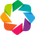

Row
    [0] HoloViews(DynamicMap, sizing_mode='fixed')
    [1] WidgetBox(align=('end', 'start'))
        [0] DiscreteSlider(name='date', options={'2000-03-31 00:00:00': np...}, value=np.datetime64('2000-03-31T...)

In [13]:
hv.extension("bokeh")
minlim = mlt_pot_yield.HWAH.min().values
maxlim = mlt_pot_yield.HWAH.max().values

mltmap = summ_yield.HWAH.hvplot.image(x='x', y='y', groupby = 'date',frame_height = 600, frame_width= 400, cmap='YlGnBu', fontscale=1.6, crs='EPSG:4326', tiles = 'EsriImagery', clim=(minlim,maxlim))

dmap_panel = pn.panel(mltmap)
dmap_panel


In [ ]:
import hvplot.pandas
boxplot = summ_yield.HWAH.hvplot.box('HWAH', by=['date'], rot=90, box_fill_color='lightblue', width=1600, height=450).opts(ylim=(1285,9969))
dmap_panel = pn.panel(boxplot)
dmap_panel

HoloViews(BoxWhisker, height=450, sizing_mode='fixed', width=1600)

### crop simulation in one run

In [ ]:
!python create_crop_weather_dssat_files.py --config options/generate_dssat_files_per_aoi_and_group.yaml


'/content/drive/MyDrive/CIAT/agwise/summarized_simulations_MWI_Zomba.nc'